In [81]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



In [82]:
# data upload and pass processing

f = 'melb_data.csv'
df_original = pd.read_csv(f)

#It's logical that the unit doesn`t have a land plot
df_original.loc[(df_original.Type == 'u') & (df_original.Landsize.isnull()),'Landsize'] = 0

#Missing parking info probably means no parking space is available
df_original["Car"] = df_original["Car"].fillna(0)


target_col = "Price"

feature_cols = [
    "Rooms",
    "Bedroom2",
    "Bathroom",
    "Car",
    "Landsize",
    "BuildingArea",
    "YearBuilt",
    "Distance",
    "Lattitude",
    "Longtitude",
    "Propertycount",
]

df_base = df_original[feature_cols + [target_col]].copy()
df = df_base.dropna()




In [83]:
#dataset size

df_columns = df.columns.tolist()[1:]

print(f"Розмір датасету: {df_original.shape[0]} рядків × {df_original.shape[1]} стовпців")
print(f"Стовпці ({len(df_columns)}): {', '.join(df_columns)}")

print(f"Розмір датасету без зпйвих даних: {df.shape[0]} рядків × {df.shape[1]} стовпців")
print(f"Стовпці ({len(df_columns)}): {', '.join(df_columns)}")

Розмір датасету: 13580 рядків × 21 стовпців
Стовпці (11): Bedroom2, Bathroom, Car, Landsize, BuildingArea, YearBuilt, Distance, Lattitude, Longtitude, Propertycount, Price
Розмір датасету без зпйвих даних: 6858 рядків × 12 стовпців
Стовпці (11): Bedroom2, Bathroom, Car, Landsize, BuildingArea, YearBuilt, Distance, Lattitude, Longtitude, Propertycount, Price


<Axes: >

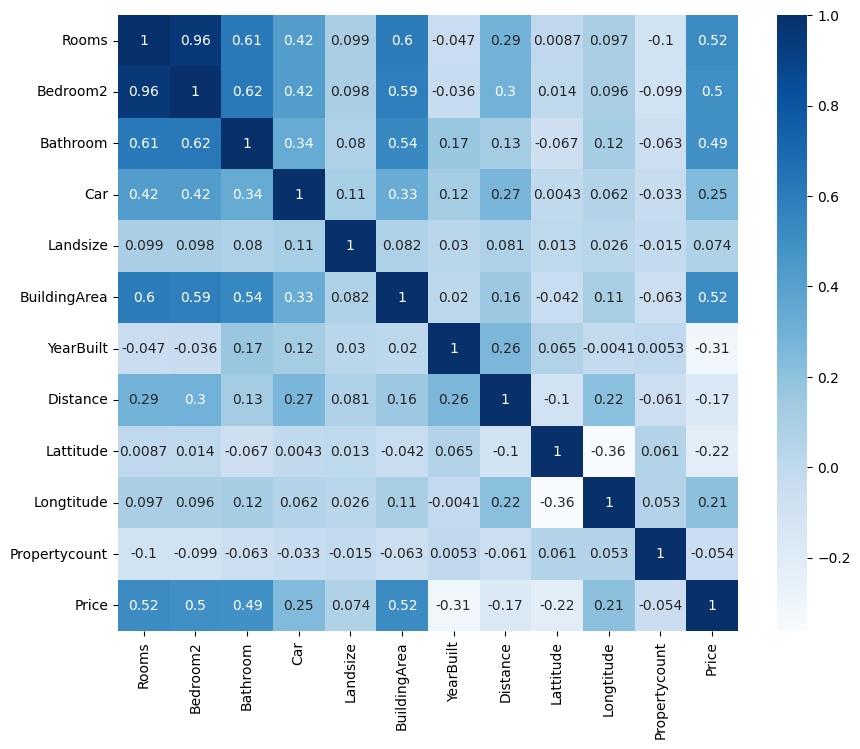

In [84]:
# correlation and heatmap

corr_matrix = df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap="Blues")



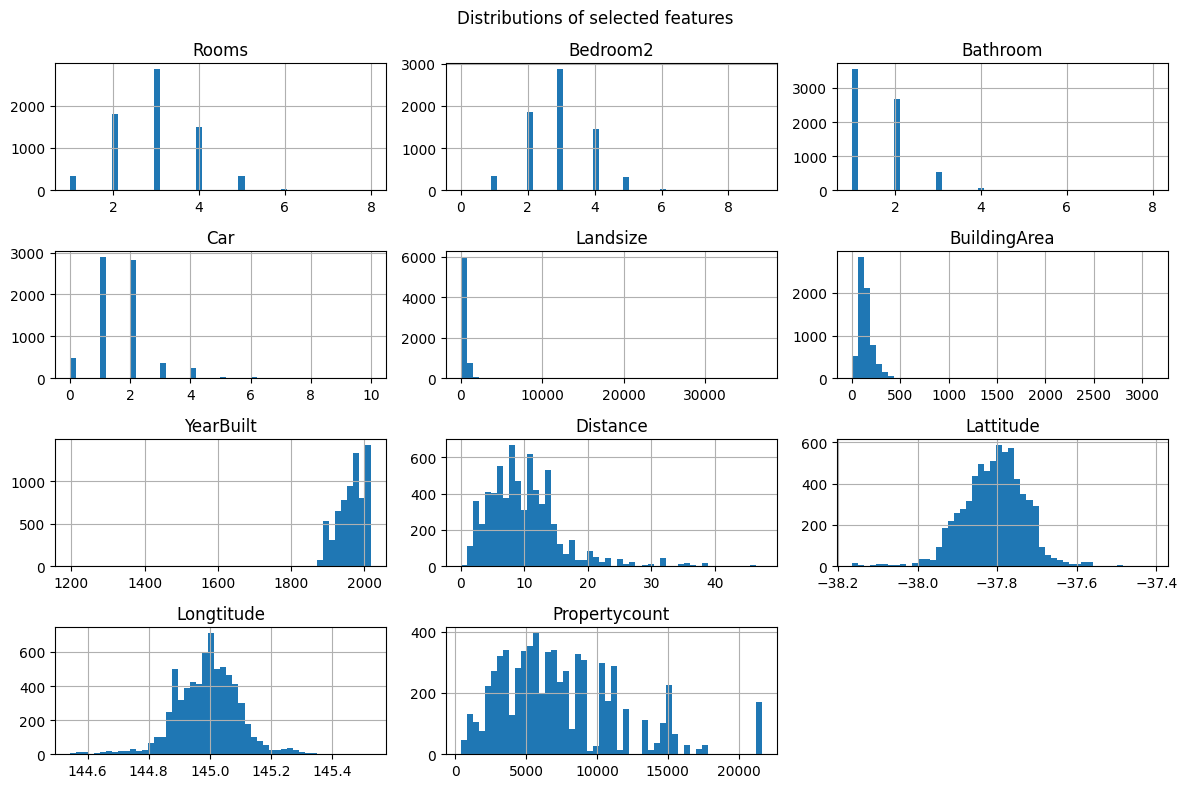

In [85]:
#feature histograms

df[feature_cols].hist(bins=50, figsize=(12, 8))
plt.suptitle("Distributions of selected features")
plt.tight_layout()
plt.show()

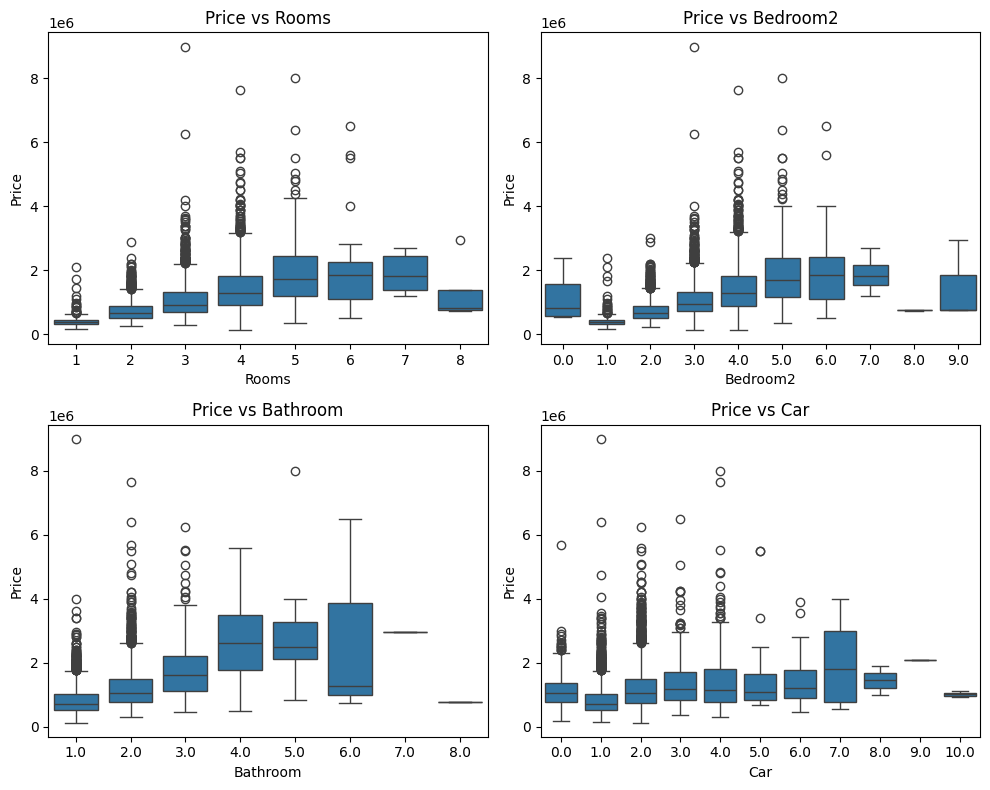

In [86]:
# boxplots

boxplot_cols = [
    "Rooms",
    "Bedroom2",
    "Bathroom",
    "Car",
]


fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.ravel()

for i, col in enumerate(boxplot_cols):
    sns.boxplot( data=df, x=col, y=target_col, ax=axes[i])
    axes[i].set_title(f"{target_col} vs {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel(target_col)

plt.tight_layout()
plt.show()

In [87]:
#Normalization

from mlxtend.preprocessing import minmax_scaling

df_normal = df.copy()
df_normal[feature_cols] = minmax_scaling(df[feature_cols], columns=feature_cols)

df_normal.head()


,Rooms,Bedroom2,Bathroom,Car,Landsize,BuildingArea,YearBuilt,Distance,Lattitude,Longtitude,Propertycount,Price
1,0.142857,0.222222,0.000000,0.0,0.004216,0.025386,0.856448,0.052743,0.472005,0.458373,0.170735,1035000.0
2,0.285714,0.333333,0.142857,0.0,0.003622,0.048201,0.856448,0.052743,0.470154,0.459389,0.170735,1465000.0
4,0.428571,0.333333,0.000000,0.2,0.003243,0.045630,0.995134,0.052743,0.472931,0.459085,0.170735,1600000.0
6,0.285714,0.444444,0.142857,0.0,0.006622,0.067481,0.868613,0.052743,0.479277,0.464369,0.170735,1876000.0
7,0.142857,0.222222,0.000000,0.2,0.006919,0.034383,0.844282,0.052743,0.474517,0.460406,0.170735,1636000.0


In [88]:
#classifier training

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.metrics import accuracy_score

df_normal["PriceClass"] = pd.qcut(df_normal[target_col], q=4, labels=False).astype(int)

X = df_normal[feature_cols]
y = df_normal["PriceClass"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


models = {'kNN': KNeighborsClassifier(), 'DecisionTree': DecisionTreeClassifier(random_state=42), 'SVM': SVC(), 'RandomForest': RandomForestClassifier(random_state=42), 'AdaBoost': AdaBoostClassifier(random_state=42)}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results[name] = (model, acc)
    print(f"{name}: test accuracy = {acc:.3f}")

print(models)

kNN: test accuracy = 0.616
DecisionTree: test accuracy = 0.641
SVM: test accuracy = 0.660
RandomForest: test accuracy = 0.731
AdaBoost: test accuracy = 0.593
{'kNN': KNeighborsClassifier(), 'DecisionTree': DecisionTreeClassifier(random_state=42), 'SVM': SVC(), 'RandomForest': RandomForestClassifier(random_state=42), 'AdaBoost': AdaBoostClassifier(random_state=42)}


In [89]:
#optimal parameters for kNN

from sklearn.model_selection import GridSearchCV

knn = KNeighborsClassifier()

param_grid_knn = {"n_neighbors": [3, 5, 7, 9, 11], "weights": ["uniform", "distance"]}
grid_knn = GridSearchCV(estimator=knn, param_grid=param_grid_knn, cv=5, scoring="accuracy", n_jobs=-1)
grid_knn.fit(X_train, y_train)
best_knn = grid_knn.best_estimator_

print("Best kNN params:", grid_knn.best_params_)
print("Best kNN CV accuracy:", grid_knn.best_score_)

y_pred_knn = best_knn.predict(X_test)
acc_knn = accuracy_score(y_test, y_pred_knn)
print("kNN test accuracy (tuned):", acc_knn)

Best kNN params: {'n_neighbors': 9, 'weights': 'distance'}
Best kNN CV accuracy: 0.6270515879538998
kNN test accuracy (tuned): 0.642128279883382


In [90]:
#optimal parameters for SVM

svm = SVC(kernel="rbf")

param_grid_svm = { "C": [0.1, 1, 10, 100], "gamma": [0.001, 0.01, 0.1, 1]}

grid_svm = GridSearchCV(estimator=svm, param_grid=param_grid_svm, cv=5, scoring="accuracy", n_jobs=-1)
grid_svm.fit(X_train, y_train)

best_svm = grid_svm.best_estimator_
print("Best SVM params:", grid_svm.best_params_)
print("Best SVM CV accuracy:", grid_svm.best_score_)

y_pred_svm = best_svm.predict(X_test)
acc_svm = accuracy_score(y_test, y_pred_svm)
print("SVM test accuracy (tuned):", acc_svm)

results["SVM"] = (best_svm, acc_svm)


Best SVM params: {'C': 100, 'gamma': 1}
Best SVM CV accuracy: 0.6749907430930191
SVM test accuracy (tuned): 0.6960641399416909


In [91]:
#best model

from sklearn.metrics import classification_report, confusion_matrix

best_name = max(results, key=lambda name: results[name][1])
best_model, best_acc = results[best_name]

print(f"\nBest model: {best_name} with test accuracy = {best_acc:.3f}")

y_pred_best = best_model.predict(X_test)

print(classification_report(y_test, y_pred_best))
print(confusion_matrix(y_test, y_pred_best))


Best model: RandomForest with test accuracy = 0.731
              precision    recall  f1-score   support

           0       0.82      0.85      0.83       345
           1       0.65      0.62      0.64       341
           2       0.63      0.64      0.64       343
           3       0.82      0.81      0.81       343

    accuracy                           0.73      1372
   macro avg       0.73      0.73      0.73      1372
weighted avg       0.73      0.73      0.73      1372

[[294  46   5   0]
 [ 63 212  63   3]
 [  3  63 220  57]
 [  0   5  61 277]]
